# AI-Based Groundwater Level Prediction and Anomaly Detection System

This project uses machine learning and deep learning techniques to
analyze groundwater level data, detect anomalies in sensor readings,
and predict future water levels using an LSTM neural network.

In [25]:
# Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler
from sklearn.ensemble import IsolationForest
from sklearn.metrics import mean_squared_error , mean_absolute_error

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

import plotly.express as px

In [26]:
# Load Dataset

df = pd.read_excel("WaterLevel_Data_clean.xlsx")

df.head()

,Name,PlotName,DeviceID,CreateDate,WaterLevel
0,Gurpal,Plot1,a840412e9187c181,2024-06-02 19:59:33,-6.5
1,Gurpal,Plot1,a840412e9187c181,2024-06-02 23:59:33,-6.5
2,Gurpal,Plot1,a840412e9187c181,2024-06-03 03:59:34,-6.5
3,Gurpal,Plot1,a840412e9187c181,2024-06-03 07:59:34,-6.5
4,Gurpal,Plot1,a840412e9187c181,2024-06-03 11:57:00,-6.5


In [27]:
# Dataset Information

df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51337 entries, 0 to 51336
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   Name        51337 non-null  object        
 1   PlotName    51337 non-null  object        
 2   DeviceID    51337 non-null  object        
 3   CreateDate  51337 non-null  datetime64[ns]
 4   WaterLevel  51337 non-null  float64       
dtypes: datetime64[ns](1), float64(1), object(3)
memory usage: 2.0+ MB


,CreateDate,WaterLevel
count,51337,51337.000000
mean,2024-08-23 23:38:49.785612800,-2.455256
min,2024-04-28 02:32:31,-8.000000
25%,2024-07-27 21:31:38,-6.500000
50%,2024-08-27 05:59:32,-2.500000
75%,2024-09-21 17:03:46,1.500000
max,2024-11-08 10:41:01,4.000000
std,NaN,4.105902


In [28]:
# Data Cleaning

df.isnull().sum()


Name          0
PlotName      0
DeviceID      0
CreateDate    0
WaterLevel    0
dtype: int64

In [29]:
# Handle missing data.

df = df.dropna()

In [31]:
# Convert Date Column

df['CreateDate'] = pd.to_datetime(df['CreateDate'])

df = df.sort_values("CreateDate")

In [8]:
# Feature Engineering

df['year'] = df['CreateDate'].dt.year
df['month'] = df['CreateDate'].dt.month
df['day'] = df['CreateDate'].dt.day
df['hour'] = df['CreateDate'].dt.hour
df['dayofweek'] = df['CreateDate'].dt.dayofweek

In [9]:
df.head()

,Name,PlotName,DeviceID,CreateDate,WaterLevel,year,month,day,hour,dayofweek
45604,Raj Kumar singh,Plot2,a84041be1187c15b,2024-04-28 02:32:31,0.0,2024,4,28,2,6
45605,Raj Kumar singh,Plot2,a84041be1187c15b,2024-04-28 06:32:30,0.0,2024,4,28,6,6
45606,Raj Kumar singh,Plot2,a84041be1187c15b,2024-04-28 14:32:27,0.0,2024,4,28,14,6
45607,Raj Kumar singh,Plot2,a84041be1187c15b,2024-04-28 18:32:26,0.0,2024,4,28,18,6
45608,Raj Kumar singh,Plot2,a84041be1187c15b,2024-04-28 22:32:25,0.0,2024,4,28,22,6


# Exploratory Data Analysis



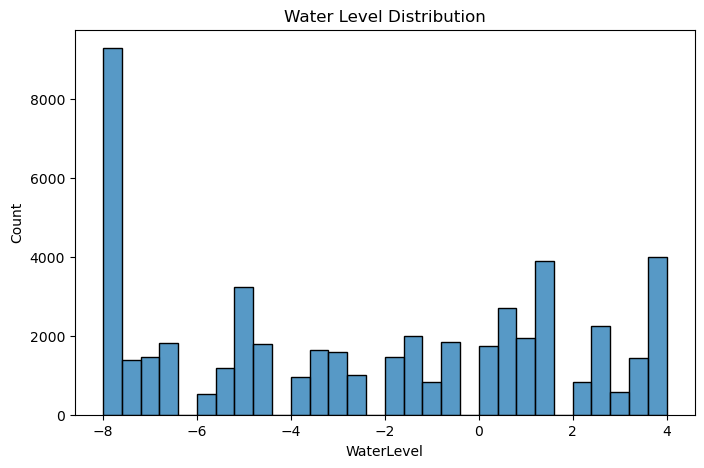

In [32]:
plt.figure(figsize=(8,5))
sns.histplot(df["WaterLevel"], bins=30)
plt.title("Water Level Distribution")
plt.show()

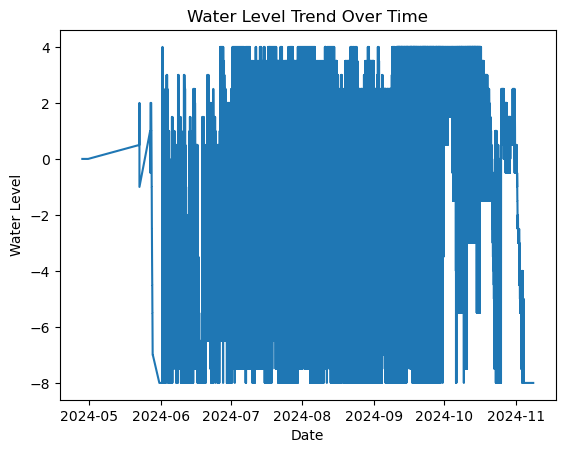

In [35]:
# Water Level Trend Over Time

plt.figure()

plt.plot(df['CreateDate'], df['WaterLevel'])

plt.title("Water Level Trend Over Time")
plt.xlabel("Date")
plt.ylabel("Water Level")

plt.show()



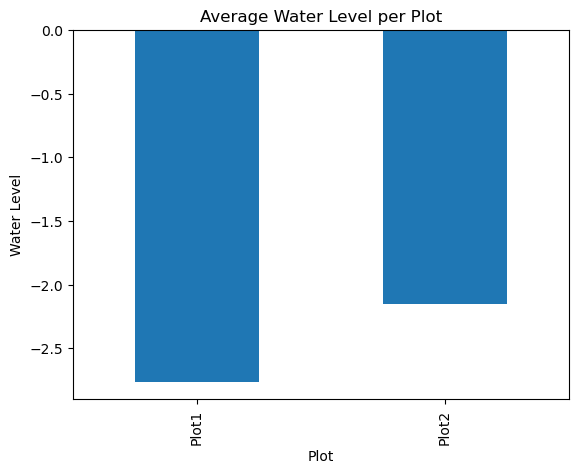

In [12]:
# Plot-wise Water Level


plot_avg = df.groupby("PlotName")["WaterLevel"].mean()

plt.figure()

plot_avg.plot(kind='bar')

plt.title("Average Water Level per Plot")
plt.xlabel("Plot")
plt.ylabel("Water Level")

plt.show()

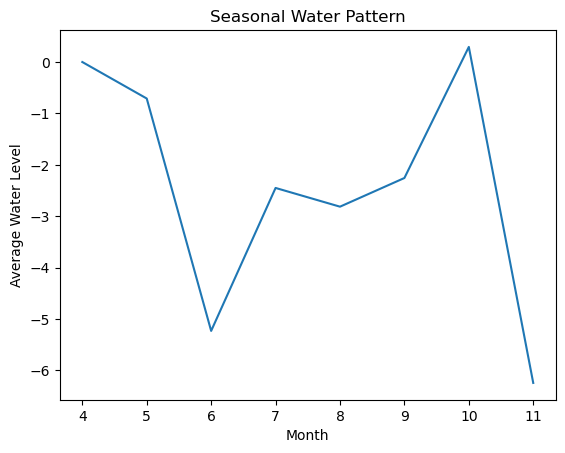

In [13]:
## Seasonal Water Pattern Detection

# This shows monthly seasonal changes in groundwater.

monthly_avg = df.groupby("month")["WaterLevel"].mean()

plt.figure()

monthly_avg.plot()

plt.title("Seasonal Water Pattern")
plt.xlabel("Month")
plt.ylabel("Average Water Level")

plt.show()

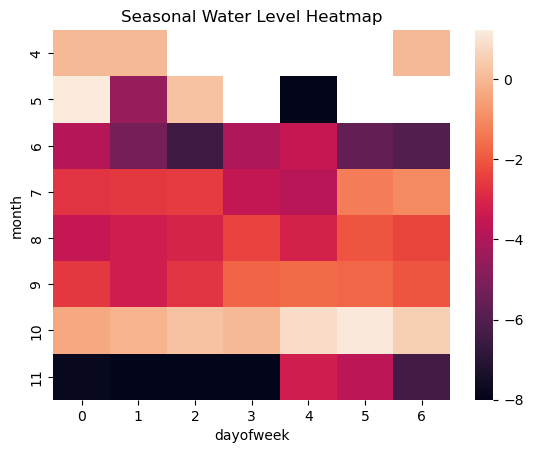

In [14]:
#Seasonal Heatmap 

pivot = df.pivot_table(values="WaterLevel",
                       index="month",
                       columns="dayofweek")

plt.figure()

sns.heatmap(pivot)

plt.title("Seasonal Water Level Heatmap")

plt.show()

In [15]:
# LSTM Deep Learning Water Prediction

data = df[['WaterLevel']]

scaler = MinMaxScaler()

scaled_data = scaler.fit_transform(data)

In [16]:
# Create Time Series Sequences

X = []
y = []

window = 24

for i in range(window, len(scaled_data)):
    
    X.append(scaled_data[i-window:i])
    y.append(scaled_data[i])

X = np.array(X)
y = np.array(y)

In [17]:
# Train Test Split

split = int(len(X) * 0.8)

X_train = X[:split]
X_test = X[split:]

y_train = y[:split]
y_test = y[split:]

In [18]:
# Build LSTM Model

model = Sequential()

model.add(LSTM(50, return_sequences=True, input_shape=(X_train.shape[1],1)))

model.add(LSTM(50))

model.add(Dense(1))

model.compile(optimizer='adam', loss='mse')

C:\Users\chait\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [19]:
# Train Model

model.fit(X_train, y_train, epochs=10, batch_size=32)

Epoch 1/10
1283/1283 ━━━━━━━━━━━━━━━━━━━━ 42s 29ms/step - loss: 0.0807
Epoch 2/10
1283/1283 ━━━━━━━━━━━━━━━━━━━━ 39s 27ms/step - loss: 0.0772
Epoch 3/10
1283/1283 ━━━━━━━━━━━━━━━━━━━━ 37s 29ms/step - loss: 0.0747
Epoch 4/10
1283/1283 ━━━━━━━━━━━━━━━━━━━━ 39s 27ms/step - loss: 0.0738
Epoch 5/10
1283/1283 ━━━━━━━━━━━━━━━━━━━━ 34s 27ms/step - loss: 0.0728
Epoch 6/10
1283/1283 ━━━━━━━━━━━━━━━━━━━━ 37s 28ms/step - loss: 0.0714
Epoch 7/10
1283/1283 ━━━━━━━━━━━━━━━━━━━━ 38s 30ms/step - loss: 0.0702
Epoch 8/10
1283/1283 ━━━━━━━━━━━━━━━━━━━━ 35s 27ms/step - loss: 0.0693
Epoch 9/10
1283/1283 ━━━━━━━━━━━━━━━━━━━━ 43s 28ms/step - loss: 0.0683
Epoch 10/10
1283/1283 ━━━━━━━━━━━━━━━━━━━━ 37s 29ms/step - loss: 0.0675


In [20]:
# Prediction

predictions = model.predict(X_test)

predictions = scaler.inverse_transform(predictions)
y_test_actual = scaler.inverse_transform(y_test)

321/321 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step


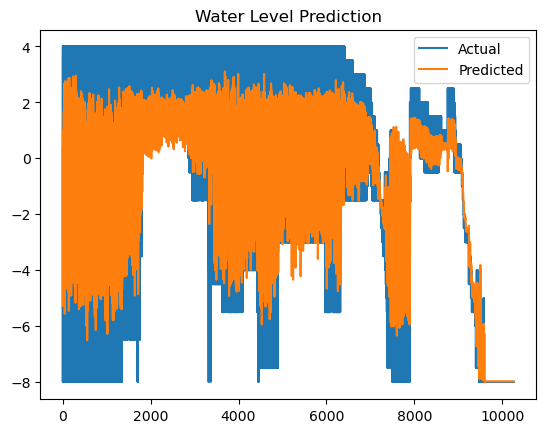

In [21]:
# Plot Prediction

plt.figure()

plt.plot(y_test_actual, label="Actual")

plt.plot(predictions, label="Predicted")

plt.legend()

plt.title("Water Level Prediction")

plt.show()

In [22]:
# Anomaly Detection (Sensor Failure Detection)

# Use Isolation Forest.

model = IsolationForest(contamination=0.01)

df['anomaly'] = model.fit_predict(df[['WaterLevel']])

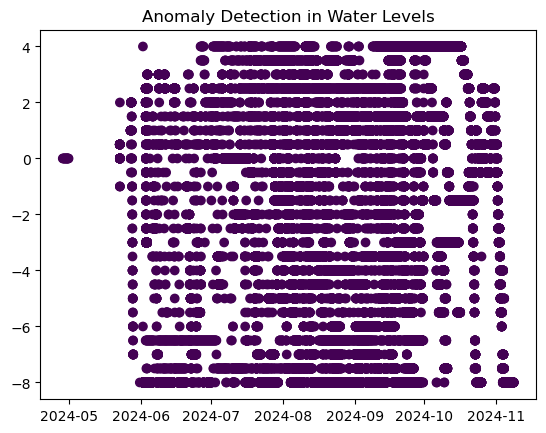

In [23]:
# Visualize Anomalies

plt.figure()

plt.scatter(df['CreateDate'], df['WaterLevel'], c=df['anomaly'])

plt.title("Anomaly Detection in Water Levels")

plt.show()

In [24]:
fig = px.line(df,
              x="CreateDate",
              y="WaterLevel",
              title="Water Level Monitoring Dashboard")

fig.show()